# 01b — Calibrate Synthetic Generator

**Purpose:** Đo đạc các thông số thống kê từ real data (1M rows) và export thành
`TierConfig` cố định dùng cho toàn bộ quá trình generate synthetic.

Notebook này **không sinh dữ liệu** và **không chạy benchmark**.
Chỉ đọc từ:
- `data/benchmark_real/` — Amazon Reviews đã tiền xử lý

---

**Nguyên tắc quan trọng (từ BENCHMARK.md 4.1):**
> The synthetic data generator MUST remain invariant with respect to dataset size.
> No recalibration when scaling from 1M → 10M → 50M → larger.

Mọi thông số được chốt **một lần duy nhất** ở notebook này.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
import json, warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("../..").resolve()
REAL_ROOT    = PROJECT_ROOT / "data" / "benchmark_real"
OUTPUT_DIR   = PROJECT_ROOT / "configs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Dùng 1M để calibrate — đủ đại diện, không tốn RAM
CALIBRATE_SIZE = "1M"
REAL_DIR       = REAL_ROOT / CALIBRATE_SIZE

print(f"Project root : {PROJECT_ROOT}")
print(f"Real data    : {REAL_DIR}")
print(f"Config output: {OUTPUT_DIR}")
print(f"Exists       : {REAL_DIR.exists()}")


Project root : D:\Polar vs Dask
Real data    : D:\Polar vs Dask\data\benchmark_real\1M
Config output: D:\Polar vs Dask\configs
Exists       : True


## 2. Load Data

In [2]:
parquet_files = sorted(REAL_DIR.rglob("*.parquet"))
jsonl_files   = sorted(REAL_DIR.rglob("*.jsonl"))

if parquet_files:
    df = pd.concat([pd.read_parquet(p) for p in parquet_files], ignore_index=True)
    print(f"Loaded {len(parquet_files)} parquet file(s)")
elif jsonl_files:
    df = pd.concat([pd.read_json(p, lines=True) for p in jsonl_files], ignore_index=True)
    print(f"Loaded {len(jsonl_files)} jsonl file(s)")
else:
    raise FileNotFoundError(f"Không tìm thấy file trong {REAL_DIR}")

TEXT_COL   = "review_text"
RATING_COL = "rating"
USER_COL   = "user_id"
ITEM_COL   = "parent_asin"

df["text_len"] = df[TEXT_COL].fillna("").astype(str).str.len()

print(f"Shape  : {df.shape}")
print(f"Memory : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head(3)

Loaded 2 parquet file(s)
Shape  : (1000000, 11)
Memory : 644.8 MB


,review_id,user_id,product_id,parent_asin,rating,review_title,review_text,review_time,helpful_vote,verified_purchase,text_len
0,R5071732930,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B096S6LZV4,B09NSZ5QMF,3,Arrived Damaged : liquid in hub locker!,"Unfortunately Amazon in their wisdom (cough, c...",2023-03-04,0,True,1719
1,R6199037955,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B09KMDBDCN,B08NGL3X17,3,Useless under 40 degrees.,Useless under 40 degrees unless you’re just ru...,2023-02-22,0,False,2305
2,R7070878004,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B096N5WK8Q,B07RGM3DYC,4,"Not waterproof, but a very comfy shoe.",I purchased these bc they are supposed to be w...,2023-02-04,11,True,1951


## 3. Calibrate Text Length Distribution

**Mục tiêu:** Tìm `text_min_len` và `text_max_len` phản ánh đúng phân phối thực.

Generator dùng Normal distribution clip tại [min, max].
Ta chọn:
- `text_min_len` ≈ p5 (loại bỏ outlier cực ngắn)
- `text_max_len` ≈ p85 (kiểm soát RAM, tránh extreme outlier)


In [3]:
text_len = df["text_len"]

p5  = int(text_len.quantile(0.05))
p25 = int(text_len.quantile(0.25))
p50 = int(text_len.quantile(0.50))
p75 = int(text_len.quantile(0.75))
p85 = int(text_len.quantile(0.85))
p90 = int(text_len.quantile(0.90))
p95 = int(text_len.quantile(0.95))
p99 = int(text_len.quantile(0.99))

print("=== Text Length Quantiles ===")
for name, val in [("p5",p5),("p25",p25),("p50",p50),("p75",p75),
                  ("p85",p85),("p90",p90),("p95",p95),("p99",p99)]:
    print(f"  {name}: {val:>6} chars")

print(f"\n  mean : {text_len.mean():.1f}")
print(f"  std  : {text_len.std():.1f}")
print(f"  skew : {text_len.skew():.3f}")

# Log-normal fit
log_vals = np.log(text_len.clip(lower=1))
mu_ln    = log_vals.mean()
sigma_ln = log_vals.std()
print(f"\n  log-normal μ = {mu_ln:.4f}")
print(f"  log-normal σ = {sigma_ln:.4f}")


=== Text Length Quantiles ===
  p5:     12 chars
  p25:     51 chars
  p50:    122 chars
  p75:    259 chars
  p85:    374 chars
  p90:    472 chars
  p95:    654 chars
  p99:   1234 chars

  mean : 204.0
  std  : 261.7
  skew : 4.708

  log-normal μ = 4.7010
  log-normal σ = 1.1984


## Calibrate Text Length Distribution

Mục tiêu của bước này là chọn khoảng độ dài text phù hợp cho synthetic generator. Từ phân phối thực, độ dài `review_text` có median **122 chars**, mean **204 chars**, p90 **472 chars**, và p99 **1,234 chars**. Phân phối bị lệch phải mạnh với `skew = 4.708`, cho thấy phần lớn review ngắn nhưng vẫn tồn tại một nhóm nhỏ review rất dài.

Trong generator hiện tại, text length được sinh bằng Normal distribution và clip trong khoảng `[text_min_len, text_max_len]`. Vì vậy, ta chọn:

- `text_min_len = p5 = 12 chars`
- `text_max_len = p85 = 374 chars`

Cách chọn này giúp loại bỏ các review quá ngắn và kiểm soát các extreme outlier ở phần đuôi phải, từ đó giảm áp lực RAM khi sinh dữ liệu lớn. Tuy nhiên, do dữ liệu thật có long-tail rõ rệt, Normal distribution sau khi clip chỉ là một xấp xỉ thực dụng, không mô phỏng đầy đủ phần đuôi dài của dữ liệu thật.

Kết quả log-normal fit cũng được lưu lại:

```text
mu    = 4.7010
sigma = 1.1984

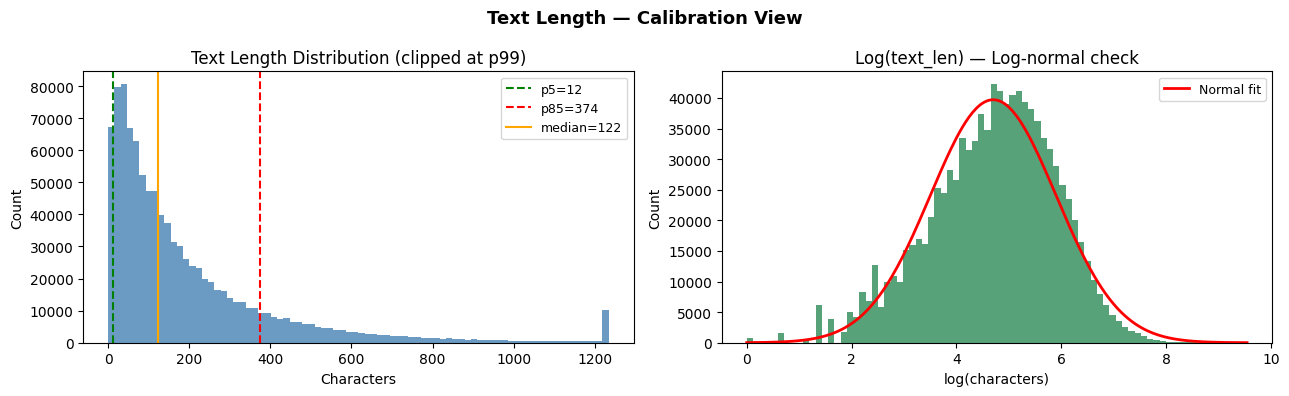

Saved: calibrate_text_len.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(text_len.clip(upper=p99), bins=80, color="steelblue", alpha=0.8, edgecolor="none")
ax.axvline(p5,  color="green",  linestyle="--", linewidth=1.5, label=f"p5={p5}")
ax.axvline(p85, color="red",    linestyle="--", linewidth=1.5, label=f"p85={p85}")
ax.axvline(text_len.median(), color="orange", linestyle="-",  linewidth=1.5,
           label=f"median={int(text_len.median())}")
ax.set_title("Text Length Distribution (clipped at p99)")
ax.set_xlabel("Characters"); ax.set_ylabel("Count")
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(np.log(text_len.clip(lower=1)), bins=80, color="seagreen", alpha=0.8, edgecolor="none")
xs = np.linspace(log_vals.min(), log_vals.max(), 300)
scale = len(text_len) * (log_vals.max() - log_vals.min()) / 80
ax.plot(xs, scale * stats.norm.pdf(xs, mu_ln, sigma_ln),
        color="red", linewidth=2, label="Normal fit")
ax.set_title("Log(text_len) — Log-normal check")
ax.set_xlabel("log(characters)"); ax.set_ylabel("Count")
ax.legend(fontsize=9)

plt.suptitle("Text Length — Calibration View", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Text Length Calibration View

Biểu đồ calibration cho thấy độ dài `review_text` trong real data vẫn có dạng **lệch phải mạnh** ngay cả khi đã clipping tại p99. Phần lớn review tập trung ở vùng độ dài thấp, trong khi phần đuôi kéo dài về phía các review dài hơn.

Dựa trên các quantile, ta chọn:

```text
text_min_len = p5  = 12 chars
text_max_len = p85 = 374 chars
```

Khoảng này được chọn để phục vụ generator hiện tại, vốn sinh text length bằng Normal distribution và clip trong [min, max]. Việc dùng p5 giúp loại bỏ các review quá ngắn, còn p85 giúp kiểm soát các review quá dài để giảm áp lực RAM khi sinh dữ liệu synthetic ở quy mô lớn.

Biểu đồ `log(text_len)` cho thấy sau khi lấy log, phân phối có dạng gần Normal hơn. Điều này xác nhận rằng phân phối text length thật phù hợp hơn với log-normal distribution. Vì vậy, các tham số log-normal vẫn nên được lưu lại như reference cho synthetic generator:

```text
mu    = 4.7010
sigma = 1.1984
```

Cần lưu ý rằng Normal distribution sau khi clip chỉ là một xấp xỉ thực dụng để kiểm soát memory, không mô phỏng đầy đủ long-tail của dữ liệu thật. Nếu generator được cải tiến sau này, nên ưu tiên sinh text length trực tiếp bằng log-normal distribution để phản ánh tốt hơn phân phối thực tế.

## 4. Calibrate User ID Reuse Probability

**Mục tiêu:** Tính `id_pool_reuse_prob` = tỉ lệ rows dùng lại user_id đã có trong pool.

Công thức gần đúng:
```
reuse_prob = 1 - (unique_users / total_rows)
```


In [5]:
total_rows   = len(df)
unique_users = df[USER_COL].nunique()
unique_items = df[ITEM_COL].nunique()

reuse_prob_user = 1.0 - unique_users / total_rows
reuse_prob_item = 1.0 - unique_items / total_rows

# User frequency → Zipf check
user_freq = df[USER_COL].value_counts().values

print("=== User ID Statistics ===")
print(f"  total_rows   : {total_rows:,}")
print(f"  unique_users : {unique_users:,}")
print(f"  reuse_prob   : {reuse_prob_user:.4f}")
print(f"  top-1 freq   : {user_freq[0]:,}")
print(f"  median freq  : {int(np.median(user_freq))}")
print(f"  % users with 1 review: {(user_freq == 1).mean()*100:.1f}%")

print("\n=== Item (parent_asin) Statistics ===")
print(f"  unique_items : {unique_items:,}")
print(f"  reuse_prob   : {reuse_prob_item:.4f}")


=== User ID Statistics ===
  total_rows   : 1,000,000
  unique_users : 119,926
  reuse_prob   : 0.8801
  top-1 freq   : 4,294
  median freq  : 4
  % users with 1 review: 21.8%

=== Item (parent_asin) Statistics ===
  unique_items : 476,112
  reuse_prob   : 0.5239


## Calibrate User ID Reuse Probability

Mục tiêu của bước này là ước lượng xác suất một row mới sẽ dùng lại `user_id` đã tồn tại trong pool, thay vì tạo một `user_id` mới. Tham số này được gọi là `id_pool_reuse_prob`.

Công thức xấp xỉ được sử dụng là:

```text
reuse_prob = 1 - (unique_users / total_rows)
```
Với 1,000,000 rows và 119,926 unique users, ta có:
```
user_id reuse_prob = 0.8801
```
Điều này có nghĩa là khoảng 88.01% rows dùng lại user đã xuất hiện trước đó, trong khi khoảng 11.99% rows tương ứng với user mới. Kết quả này phù hợp với phân tích user frequency trước đó: median user có 4 reviews, user xuất hiện nhiều nhất có 4,294 reviews, và 21.8% users chỉ có đúng một review.

Với parent_asin, có 476,112 unique items, dẫn đến:
```
item reuse_prob = 0.5239
```
Giá trị này thấp hơn đáng kể so với user_id, cho thấy product key có cardinality cao hơn và mức độ reuse thấp hơn. Nói cách khác, không gian item rộng hơn user: nhiều sản phẩm chỉ xuất hiện một vài lần, trong khi user có xu hướng được reuse nhiều hơn trong dataset.

Các tham số reuse probability này giúp synthetic generator kiểm soát mức độ lặp lại của key. Nếu reuse probability quá thấp, synthetic data sẽ có quá nhiều key mới và thiếu skew. Nếu reuse probability quá cao, dữ liệu sẽ bị tập trung vào quá ít key. Vì vậy, việc hiệu chỉnh riêng cho user_id và parent_asin là cần thiết để synthetic data phản ánh đúng cardinality và key reuse pattern của real data.

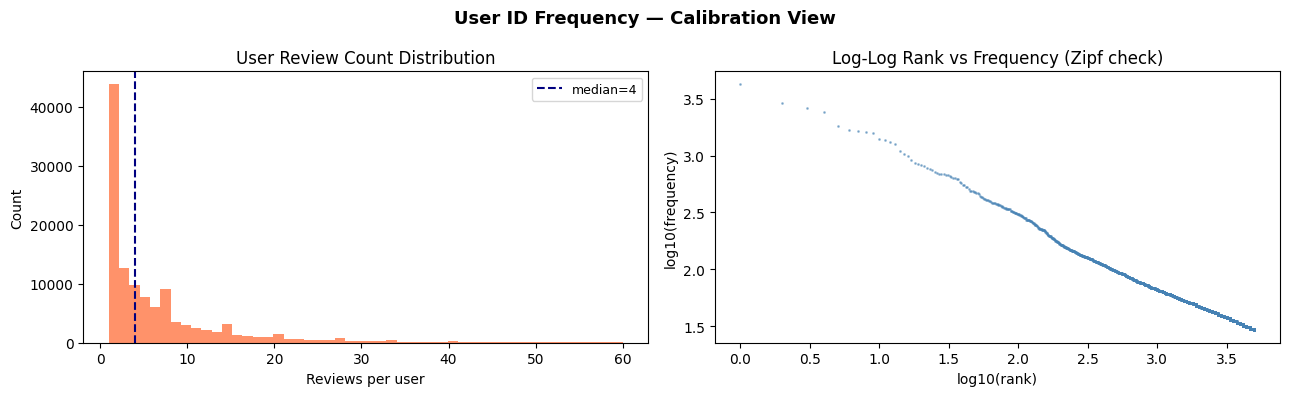

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(user_freq, bins=50, range=(1, np.percentile(user_freq, 99)),
        color="coral", alpha=0.85, edgecolor="none")
ax.set_title("User Review Count Distribution")
ax.set_xlabel("Reviews per user"); ax.set_ylabel("Count")
ax.axvline(np.median(user_freq), color="navy", linestyle="--", linewidth=1.5,
           label=f"median={int(np.median(user_freq))}")
ax.legend(fontsize=9)

ax = axes[1]
# Zipf: log-log rank vs frequency
ranks = np.arange(1, len(user_freq) + 1)
ax.scatter(np.log10(ranks[:5000]), np.log10(user_freq[:5000]),
           s=1, color="steelblue", alpha=0.5)
ax.set_title("Log-Log Rank vs Frequency (Zipf check)")
ax.set_xlabel("log10(rank)"); ax.set_ylabel("log10(frequency)")

plt.suptitle("User ID Frequency — Calibration View", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## User ID Frequency Calibration View

Biểu đồ user frequency cho thấy `user_id` có mức độ reuse cao và phân phối bị lệch mạnh. Phần lớn user chỉ có số lượng review thấp, trong đó median là **4 reviews/user**, nhưng vẫn tồn tại một nhóm nhỏ user có tần suất xuất hiện cao hơn nhiều.

Từ 1,000,000 rows, dữ liệu có **119,926 unique users**, nên xác suất reuse user ID được ước lượng là:

```text
id_pool_reuse_prob = 1 - unique_users / total_rows = 0.8801
```
Điều này có nghĩa là khoảng 88.01% rows sẽ dùng lại một user_id đã có trong pool, còn khoảng 11.99% rows tạo ra user mới. Tham số này giúp synthetic generator tái tạo đúng mức độ lặp lại của user key trong real data.

Biểu đồ log-log rank-frequency cũng cho thấy xu hướng giảm dần gần tuyến tính, phản ánh đặc điểm Zipf-like / power-law. Vì vậy, ngoài reuse probability, generator cũng cần giữ lại mức độ skew của user frequency, thay vì chọn user ID theo phân phối đều.

Tóm lại, `user_id` trong synthetic data nên được sinh theo cơ chế vừa có high reuse probability, vừa có skewed frequency distribution, để phản ánh đúng đặc điểm long-tail của real user activity.

## 5. Calibrate Rating Distribution

In [7]:
rating_counts  = df[RATING_COL].value_counts().sort_index()
rating_probs   = rating_counts / rating_counts.sum()

print("=== Rating Distribution ===")
for r, p in rating_probs.items():
    bar = "█" * int(p * 40)
    print(f"  {r} stars: {p:.4f}  {bar}")

print(f"\n  As list (1→5): {[round(float(rating_probs.get(i, 0)), 4) for i in range(1, 6)]}")


=== Rating Distribution ===
  1 stars: 0.0579  ██
  2 stars: 0.0504  ██
  3 stars: 0.0909  ███
  4 stars: 0.1629  ██████
  5 stars: 0.6379  █████████████████████████

  As list (1→5): [0.0579, 0.0504, 0.0909, 0.1629, 0.6379]


## Calibrate Rating Distribution

`rating` là categorical feature với 5 giá trị từ 1 đến 5. Phân phối thực tế cho thấy rating không đều, mà bị lệch mạnh về phía rating cao.

Trong 1M rows, rating **5 sao** chiếm tỷ lệ lớn nhất với **63.79%**, trong khi rating **4 sao** chiếm **16.29%**. Như vậy, nhóm rating 4–5 sao chiếm hơn **80%** tổng số review. Các rating thấp hơn xuất hiện ít hơn đáng kể: rating 1 sao chiếm **5.79%**, rating 2 sao chiếm **5.04%**, và rating 3 sao chiếm **9.09%**.

Vì phân phối rating bị mất cân bằng rõ rệt, synthetic generator không nên sinh rating theo uniform distribution. Thay vào đó, nên sử dụng empirical probabilities từ real data:

```text
rating_probs = [0.0579, 0.0504, 0.0909, 0.1629, 0.6379]
```
Cách này giúp synthetic data giữ lại xu hướng tích cực của real dataset, đặc biệt là việc rating 5 sao chiếm ưu thế.

## 6. Frozen TierConfig — Final Parameters

In [8]:
# ─────────────────────────────────────────────────────────
# FROZEN PARAMETERS — DO NOT RECALIBRATE PER DATASET SIZE
# ─────────────────────────────────────────────────────────

FROZEN_CONFIG = {
    # Text length — based on p5 / p85 of real data
    "text_min_len":        p5,
    "text_max_len":        p85,
    "text_variants":       2000,        # đủ entropy, không recalibrate
    "random_insert_prob":  0.02,

    # ID reuse — based on 1M real data measurement
    "id_pool_reuse_prob":  round(float(min(0.98, reuse_prob_user)), 4),

    # Rating distribution (empirical from real data)
    "rating_distribution": [
        round(float(rating_probs.get(i, 0)), 4)
        for i in range(1, 6)
    ],

    # Log-normal params (for reference / validation only)
    "text_len_lognormal_mu":    round(float(mu_ln), 4),
    "text_len_lognormal_sigma": round(float(sigma_ln), 4),

    # Calibration metadata
    "calibrated_from":  f"real/{CALIBRATE_SIZE}",
    "calibrated_rows":  int(total_rows),
    "calibrated_unique_users": int(unique_users),
}

print("=== FROZEN TierConfig ===")
for k, v in FROZEN_CONFIG.items():
    print(f"  {k:<32}: {v}")


=== FROZEN TierConfig ===
  text_min_len                    : 12
  text_max_len                    : 374
  text_variants                   : 2000
  random_insert_prob              : 0.02
  id_pool_reuse_prob              : 0.8801
  rating_distribution             : [0.0579, 0.0504, 0.0909, 0.1629, 0.6379]
  text_len_lognormal_mu           : 4.701
  text_len_lognormal_sigma        : 1.1984
  calibrated_from                 : real/1M
  calibrated_rows                 : 1000000
  calibrated_unique_users         : 119926


## Frozen TierConfig

Sau khi calibration từ real dataset 1M rows, các tham số chính cho synthetic generator được cố định trong `TierConfig`. Việc “freeze” config giúp đảm bảo các lần sinh synthetic data sau này sử dụng cùng một bộ tham số, tránh thay đổi phân phối giữa các benchmark run.

Đối với text length, generator hiện tại sử dụng khoảng clip từ **12** đến **374** ký tự, tương ứng với p5 và p85 của phân phối thực. Khoảng này giúp loại bỏ các text quá ngắn và kiểm soát các review quá dài để giảm áp lực bộ nhớ khi sinh dữ liệu lớn. Đồng thời, các tham số log-normal `mu = 4.701` và `sigma = 1.1984` cũng được lưu lại như reference thống kê, vì phân phối text length thật có dạng long-tail.

Tham số `id_pool_reuse_prob = 0.8801` được calibrated từ **119,926 unique users** trên tổng **1,000,000 rows**. Giá trị này cho biết phần lớn rows synthetic sẽ reuse user ID đã có trong pool, giúp tái tạo mức độ lặp lại và skew của user key trong real data.

Phân phối rating được cố định theo empirical distribution:

```text
[0.0579, 0.0504, 0.0909, 0.1629, 0.6379]
```
Điều này giúp synthetic data giữ lại đặc điểm mất cân bằng của real data, trong đó rating 5 sao chiếm tỷ lệ cao nhất.

Các tham số như `text_variants = 2000` và `random_insert_prob = 0.02` được dùng để kiểm soát mức độ đa dạng của text synthetic. Chúng giúp dữ liệu không bị lặp text quá đơn giản, nhưng vẫn giữ được chi phí sinh dữ liệu ở mức ổn định.

Nhìn chung, TierConfig này là kết quả calibration từ `real/1M` và sẽ được dùng làm cấu hình cố định cho synthetic generator. Mục tiêu là đảm bảo synthetic data giữ lại các đặc điểm quan trọng của real data: độ dài text có long-tail, user ID có mức reuse cao, rating bị skew về phía cao, và memory footprint có thể kiểm soát khi scale lên các kích thước lớn hơn.

In [9]:
# Export sang JSON để data_generator.py có thể đọc
config_path = OUTPUT_DIR / "synthetic_tier_config.json"
with open(config_path, "w") as f:
    json.dump(FROZEN_CONFIG, f, indent=2)

print(f"Saved: {config_path}")
print()
print("=== Paste vào data_generator.py / TierConfig ===")
print(f"""
TIER_CONFIGS[BenchmarkTier.TIER2] = TierConfig(
    id_pool_reuse_prob = {FROZEN_CONFIG['id_pool_reuse_prob']},
    text_min_len       = {FROZEN_CONFIG['text_min_len']},
    text_max_len       = {FROZEN_CONFIG['text_max_len']},
    text_variants      = {FROZEN_CONFIG['text_variants']},
    random_insert_prob = {FROZEN_CONFIG['random_insert_prob']},
)
""")


Saved: D:\Polar vs Dask\configs\synthetic_tier_config.json

=== Paste vào data_generator.py / TierConfig ===

TIER_CONFIGS[BenchmarkTier.TIER2] = TierConfig(
    id_pool_reuse_prob = 0.8801,
    text_min_len       = 12,
    text_max_len       = 374,
    text_variants      = 2000,
    random_insert_prob = 0.02,
)



## 7. Summary

In [10]:
print("=" * 55)
print("  CALIBRATION SUMMARY")
print("=" * 55)
print(f"  Calibrated from     : real/{CALIBRATE_SIZE} ({total_rows:,} rows)")
print(f"  text_min_len        : {FROZEN_CONFIG['text_min_len']:>6}  (p5  of real)")
print(f"  text_max_len        : {FROZEN_CONFIG['text_max_len']:>6}  (p85 of real)")
print(f"  id_pool_reuse_prob  : {FROZEN_CONFIG['id_pool_reuse_prob']:.4f}")
print(f"  text_variants       : {FROZEN_CONFIG['text_variants']:>6}  (fixed)")
print(f"  random_insert_prob  : {FROZEN_CONFIG['random_insert_prob']:.4f}  (fixed)")
print()
print("  Config saved to: config/synthetic_tier_config.json")
print()
print("  NEXT STEP: Run 01c_validate_synthetic.ipynb")
print("=" * 55)


  CALIBRATION SUMMARY
  Calibrated from     : real/1M (1,000,000 rows)
  text_min_len        :     12  (p5  of real)
  text_max_len        :    374  (p85 of real)
  id_pool_reuse_prob  : 0.8801
  text_variants       :   2000  (fixed)
  random_insert_prob  : 0.0200  (fixed)

  Config saved to: config/synthetic_tier_config.json

  NEXT STEP: Run 01c_validate_synthetic.ipynb
